In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
transform=transforms.Compose([
    transforms.Resize((299,299)),    
    transforms.ToTensor() 
])

aug_trans = transforms.Compose([
    
    transforms.Resize(224), 
    transforms.RandomCrop(128),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

In [3]:
seed = 124

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [4]:
DATA_DIR = r'/home/pcdm/Desktop/New_Plant_Diseases/train'
model_algo="googlenet"


In [5]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,trans,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root)        
        self.classes = self.images.class_to_idx.items()
        self.flag= [True] * len(self.images)
        self.decision_mode=decision_mode
        self.transform = trans

        
        # self.sum=0
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        image, label=self.images[idx]
        
        image=self.transform(image)
    
        if(self.decision_mode==True):
            label=torch.tensor(int(self.flag[idx]))
        return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = False
    

In [6]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

# generator = torch.Generator()
# generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [7]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()
idx2class = {v: k for k, v in trainset.dataset.classes}

In [8]:
#建立模型框架
def model_create(model_algo,data_name):
    model = getattr(models,model_algo)(weights=True)

    if(data_name=='decision'):
        class_number=len(trainset.dataset.classes)*2
        
    else:
        class_number=len(trainset.dataset.classes)
    

    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
        
    elif model_algo == 'inception_v3':
        # 修改輔助分類器
        num_ftrs_aux = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(num_ftrs_aux, class_number)

        # 修改最後的全連接層
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,class_number)
    
    

    return model

In [9]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        
                        loss = criterion(out, target)
                        # print(target)
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
        return total_loss,accu,confusion_matrix_valid

In [10]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                data,target=data.to(device),target.to(device)
                out_growth= model_0(data)
                _, decision_tag = torch.max(out_growth, dim = 1)
                softmax = torch.softmax(out_growth, dim=1)
                
                for softmax,d,t in zip(softmax,data,target):
                        sort_soft=sorted(softmax,reverse=True)
                        value=sort_soft[0]
                        if (TorF == "T" and value>=0.8) or (TorF == "F" and  value< 0.8):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [11]:

def evaluate_model_decision(model):
        correct=0
        flat_true=[]
        flat_pred=[]
        sum_T=0
        sum_F=0
        decision_valid_accu=0
        with torch.no_grad():
                model_0.eval()   
                for data, target,idx in valid_dl:

                        data,target=data.to(device),target.to(device)
                        out_growth= model_0(data)   #原始model
                        softmax = torch.softmax(out_growth, dim=1)
                        _, y_pred_tag = torch.max(out_growth, dim = 1)
                      
                        out_predict= model(softmax)  #預測要用哪個model
                        _, predict = torch.max(out_predict, dim = 1)
                        # ###############
                        # #以softmax切割#
                        # ###############
                        # for pred,softmax in zip(predict,softmax):
                        #         sort_soft=sorted(softmax,reverse=True)
                        #         value=sort_soft[0]
                        #         if(value < 0.8):
                        #                 result=0
                        #         else:
                        #                 result=1

                        #         if(result == pred ):
                        #                 correct+=1
                                
                        #         flat_true.append(result)
                        #         flat_pred.append(pred.cpu().numpy())


                        #################
                        #以判斷正確與否切割#
                        #################
                        for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                                # print(result,pred)
                                if(pred==result):
                                        correct+=1
                                if(pred==0):
                                        sum_F+=1
                                # print("true")
                                else:
                                        sum_T+=1
                                # print("false")
                                
                                
                                flat_true.append(result.cpu().numpy())
                                flat_pred.append(pred.cpu().numpy())
                                                        
                print(f"correct={correct}")
        decision_valid_accu=correct/valid_size
        print(f"sum_F,sum_T={sum_F,sum_T}")
        print("decision_valid accu=",decision_valid_accu) 
        confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
        return  decision_valid_accu,confusion_matrix_decision_valid

In [12]:
#訓練模型
def trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name):
        train_accus=[]
        val_accus=[]
        best_val_accu = 0.0
        epochs_without_improvement = 0
        patience=5
        best_model = None
        
                
        for epoch in range(epochs):
                
                train_loss=0
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in train_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                      
                        out= model(data)
                        # _, y_pred_tag = torch.max(out, dim = 1)  
                        
                        loss = criterion(out, target)
                        
                        loss.backward()
                        optim.step()
                        # print(target)
                
                train_loss,train_accu,_=evaluate_model(model,train_dl,len(train_dl.dataset))
                print(f"Epoch={epoch},train_loss={train_loss},train_accu={train_accu}")
                train_accus.append(train_accu)
                
                if(data_name=="T" or data_name=="F"):  
                        val_loss,val_accu,_=evaluate_model_TF(model,data_name)
                # elif(data_name=="decision"):
                #         val_accu,_=evaluate_model_decision(model)
                else:
                        val_loss,val_accu,_=evaluate_model(model,valid_dl,len(valid_dl.dataset))
                        print(f"Epoch={epoch},valid_loss={val_loss},valid_accu={val_accu}")

                val_accus.append(val_accu)
        
                # Early stopping
                if val_accu > best_val_accu:
                        best_val_accu = val_accu
                        epochs_without_improvement = 0
                        best_model=copy.deepcopy(model)
                        print(f"{epochs_without_improvement}")

                else:
                        epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                        print(f"{epochs_without_improvement} Early stopping!")
                        break

                
                torch.save(best_model, f"model_{model_algo}_{data_name}_{epoch}.pth")               
        plt.plot(train_accus,'-o')
        plt.plot(val_accus,'-o')

        plt.xlabel('epoch')
        plt.ylabel('Accuracy')
        plt.legend(['Train','Valid'])
        plt.show()
        torch.save(best_model, f"model_{model_algo}_{data_name}.pth")  
        return best_model
                

In [13]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None):
    
    model=model_create(model_algo,data_name)
    if(data_name=="decision"):
        
        optim = torch.optim.Adam(model.fc.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        
        dense1 = nn.Linear(len(trainset.dataset.classes), 224 * 224 * 3)
        reshape = nn.Unflatten(-1,(3,224, 224))
        model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name)
        
    else:
        optim = torch.optim.Adam(model.fc.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

In [14]:
# model_0 = torch.load(f'model_{model_algo}_0_14.pth')

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.6543864881176504,train_accu=0.7091419816138917
Epoch=0,valid_loss=1.6600876859579672,valid_accu=0.6882681564245811
0
Epoch=1,train_loss=1.278066069161685,train_accu=0.7871552604698672
Epoch=1,valid_loss=1.2805674553983037,valid_accu=0.7821229050279329
0
Epoch=2,train_loss=1.0613999354583616,train_accu=0.8066905005107252
Epoch=2,valid_loss=1.0666748993889579,valid_accu=0.8029050279329609
0
Epoch=3,train_loss=0.9131526575634015,train_accu=0.8201608784473953
Epoch=3,valid_loss=0.9188029168038395,valid_accu=0.8125139664804469
0
Epoch=4,train_loss=0.8195789533689146,train_accu=0.8275025536261491
Epoch=4,valid_loss=0.823191988268378,valid_accu=0.8265921787709497
0
Epoch=5,train_loss=0.7471101301074393,train_accu=0.8315245148110316
Epoch=5,valid_loss=0.7553107901392037,valid_accu=0.8227932960893855
Epoch=6,train_loss=0.6941472181747834,train_accu=0.847867722165475
Epoch=6,valid_loss=0.7022025151758886,valid_accu=0.8382122905027933
0
Epoch=7,train_loss=0.6395612151739668,t

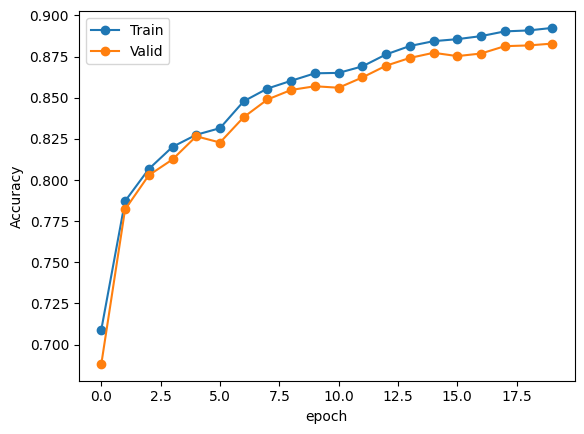

In [15]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",20)
# model_0 = torch.load(f'model_{model_algo}_0_14.pth')

In [16]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size)
train_loss,train_accu

(0.41745732707923716, 0.8924284984678243)

In [17]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size)
valid_loss,valid_accu

(0.4374106052268151, 0.8829050279329609)

In [18]:
# 將資料切分成true and false
def split_data(model_0,data_dl):
    model_0.eval()

    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            # print(loss)
            for idx,loss in zip(idx,loss):

                if(loss>0.25):
                    indexF.append(idx.cpu().numpy().item())  
                    trainset.dataset.update_flag(idx)
                elif(loss>0.2 and loss<0.25):
                    indexF.append(idx.cpu().numpy().item())  
                    indexT.append(idx.cpu().numpy().item())
            
                else:
                    indexT.append(idx.cpu().numpy().item())   
                        
            torch.cuda.empty_cache() 
        return indexF,indexT

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_0,train_dl)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(7815, 8679)

In [20]:
index_valid_F=[]
index_valid_T=[]
index_valid_F,index_valid_T=split_data(model_0,valid_dl)
len(index_valid_F),len(index_valid_T)

(2249, 2467)

In [21]:
valid_size

4475

In [22]:
#decision set

def decision_split(data_dl):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i in idx:
                flat_true.append(int(trainset.dataset.flag[i]))
        
            flat_data.extend(softmax.cpu().numpy()) 
                
    return flat_data,flat_true


In [23]:
d_data,d_target=decision_split(train_dl)

In [24]:
d_v_data,d_v_target=decision_split(valid_dl)

In [25]:
train_size

15664

In [26]:
#建立dataset class
class DecisionDataset(Dataset):
    def __init__(self, x,y):
        super().__init__()
        self.x = x        
        self.y = y
    
    def __len__(self):
        return len(self.y)
   
    def __getitem__(self,idx):

        image=self.x[idx]
  
        label=self.y[idx]
        return image,label,idx
    def get_labels(self):
        return self.y
    

In [27]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.2483536574582401,train_accu=0.9667390194075587
Epoch=0,valid_loss=0.243099216882077,valid_accu=0.9722905027932961
0
Epoch=1,train_loss=0.15733598474036442,train_accu=0.9754213483146067
Epoch=1,valid_loss=0.15335850932078654,valid_accu=0.9763128491620112
0
Epoch=2,train_loss=0.12225608174537858,train_accu=0.9769535240040857
Epoch=2,valid_loss=0.12218832472183185,valid_accu=0.9776536312849162
0
Epoch=3,train_loss=0.10682608266346788,train_accu=0.980017875383044
Epoch=3,valid_loss=0.1060679959984465,valid_accu=0.9792178770949721
0
Epoch=4,train_loss=0.09248925014508391,train_accu=0.9835291113381001
Epoch=4,valid_loss=0.09396277748672656,valid_accu=0.9812290502793296
0
Epoch=5,train_loss=0.0872734184124801,train_accu=0.983273748723187
Epoch=5,valid_loss=0.0879634114417284,valid_accu=0.9818994413407821
0
Epoch=6,train_loss=0.08002082469651478,train_accu=0.9842951991828396
Epoch=6,valid_loss=0.08147631287574768,valid_accu=0.9836871508379889
0
Epoch=7,train_loss=0.0767055

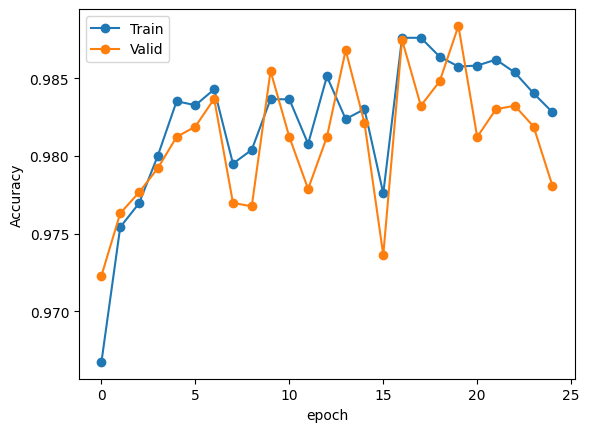

In [28]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",30)

In [29]:
# model_T=torch.load(f'model_{model_algo}_T_12.pth')

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.6092964915007348,train_accu=0.7409839843299919
Model_T valid loss=1.5983932113254464, accu=0.7489433643279797,sample_number=2366
0
Epoch=1,train_loss=1.190572990155849,train_accu=0.8473326420094481
Model_T valid loss=1.1758387939136914, accu=0.8541842772612004,sample_number=2366
0
Epoch=2,train_loss=0.9173680089739477,train_accu=0.9241848139186543
Model_T valid loss=0.9019252441836079, accu=0.9192730346576501,sample_number=2366
0
Epoch=3,train_loss=0.7300970549063689,train_accu=0.9627837308445674
Model_T valid loss=0.7149996625886174, accu=0.9590025359256128,sample_number=2366
0
Epoch=4,train_loss=0.5996677023238995,train_accu=0.9696969696969697
Model_T valid loss=0.5893184673914958, accu=0.9661876584953508,sample_number=2366
0
Epoch=5,train_loss=0.5064433103869184,train_accu=0.9701578522871298
Model_T valid loss=0.49649654289794926, accu=0.9674556213017751,sample_number=2366
0
Epoch=6,train_loss=0.4282682459809591,train_accu=0.985366977762415
Model_T valid loss=0.

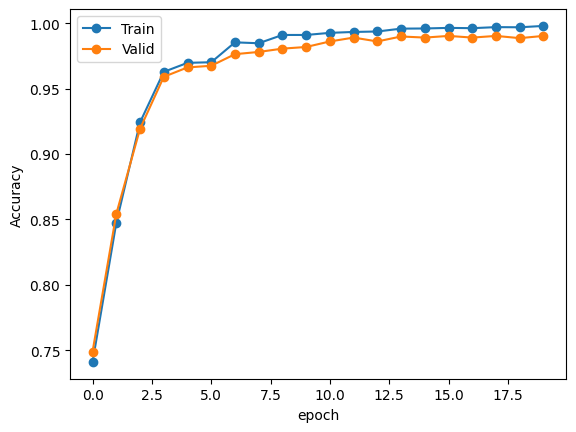

In [30]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,None,"T",20)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=2.032716611586392,train_accu=0.2981445937300064
Model_F valid loss=2.0382870959692965, accu=0.28923660502607873,sample_number=2109
0
Epoch=1,train_loss=1.8657494099263723,train_accu=0.4255918106206014
Model_F valid loss=1.877062589000785, accu=0.406827880512091,sample_number=2109
0
Epoch=2,train_loss=1.7377390833138961,train_accu=0.47715930902111325
Model_F valid loss=1.7559331563650686, accu=0.45519203413940257,sample_number=2109
0
Epoch=3,train_loss=1.6294008822450254,train_accu=0.5064619321817019
Model_F valid loss=1.6503817906533444, accu=0.4826932195353248,sample_number=2109
0
Epoch=4,train_loss=1.5372373229330043,train_accu=0.5538067818298145
Model_F valid loss=1.5631216382064657, accu=0.5381697486960645,sample_number=2109
0
Epoch=5,train_loss=1.4600829676337068,train_accu=0.5836212412028151
Model_F valid loss=1.4886741075910286, accu=0.5623518255097203,sample_number=2109
0
Epoch=6,train_loss=1.3936803167627472,train_accu=0.6310940499040307
Model_F valid loss=1

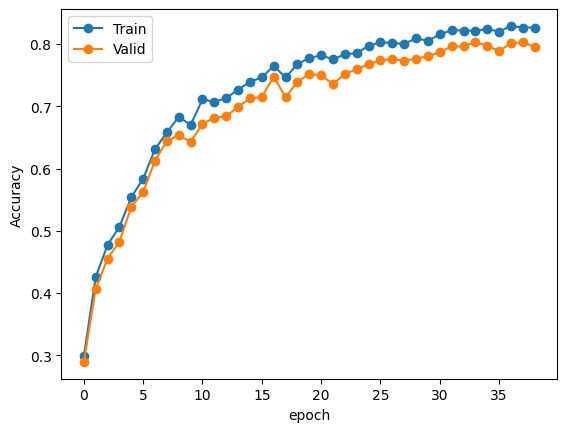

In [31]:
model_F=model_train(model_algo,Fdl,None,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [32]:
torch.cuda.empty_cache()

In [33]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset))
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"buildings":"False","forest":"True"}, index={"buildings":"False","forest":"True"})
decision_loss,decision_accu

(0.06111393581250106, 0.9860188968335035)

In [34]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v))
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.06334816413551736, 0.9883798882681564)

In [35]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset))
T_loss,T_accu

(0.16004515689041074, 0.9964281599262588)

In [36]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset))
F_loss,F_accu

(0.7566759030710637, 0.8213691618682022)

In [37]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model_TF(model_T,"T")
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model_TF(model_F,"F")

Model_T valid loss=0.17262161934970888, accu=0.9902789518174133,sample_number=2366
Model_F valid loss=0.8156119701865444, accu=0.8036984352773826,sample_number=2109


In [38]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0

    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)

            softmax=torch.softmax(out_growth, dim=1)

            out=model_decision(softmax)
            _, y_pred_tag = torch.max(out, dim = 1)
            
        
            for pred,d,t in zip(y_pred_tag,data,target):
             
                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1

                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    
           
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F

In [39]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum=total_model_evaluate(train_dl,train_size)
total_train_loss,total_train_accu,sum

(0.4547089839066865, 0.9088993871297242, 6870)

In [40]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum=total_model_evaluate(valid_dl,valid_size)
total_valid_loss,total_valid_accu,sum

(0.4778732043804403, 0.9021229050279329, 1974)

In [41]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)
    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [42]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,'NA',T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]


In [43]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.417457,0.892428,0.437411,0.882905
1,Model_Decision,0.061114,0.986019,NA,0.988380
2,Model_T,0.160045,0.996428,0.172622,0.990279
3,Model_F,0.756676,0.821369,0.815612,0.803698
4,Total_Model,0.454709,0.908899,0.477873,0.902123


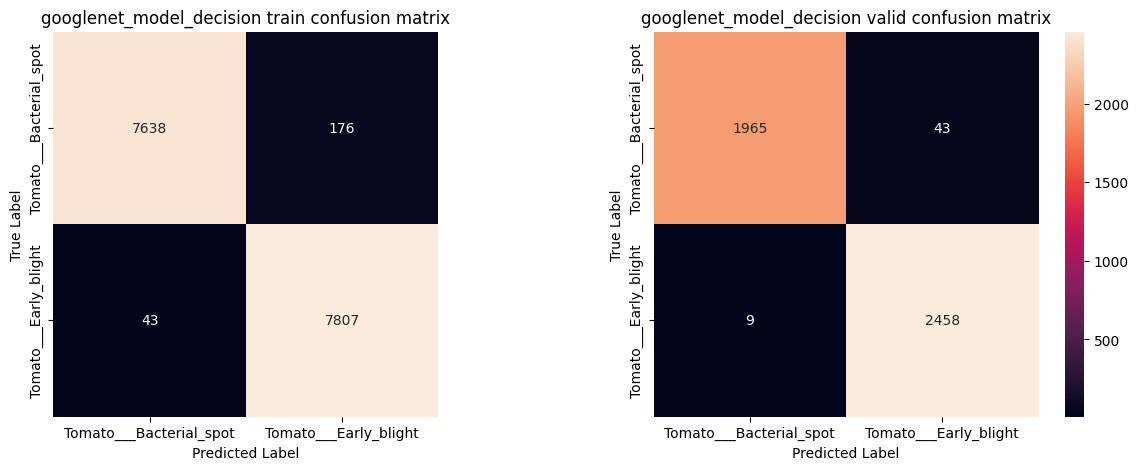

In [44]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision")

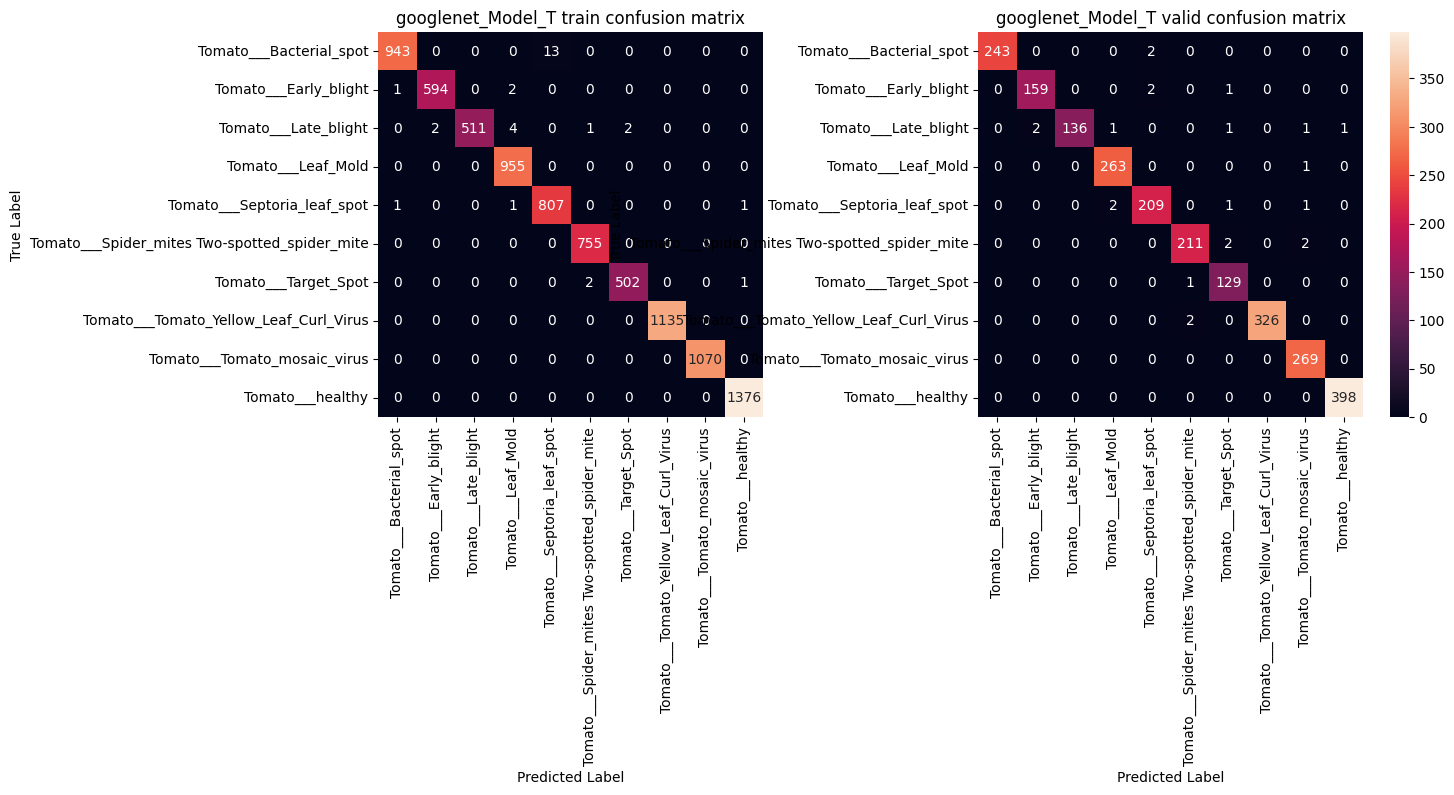

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

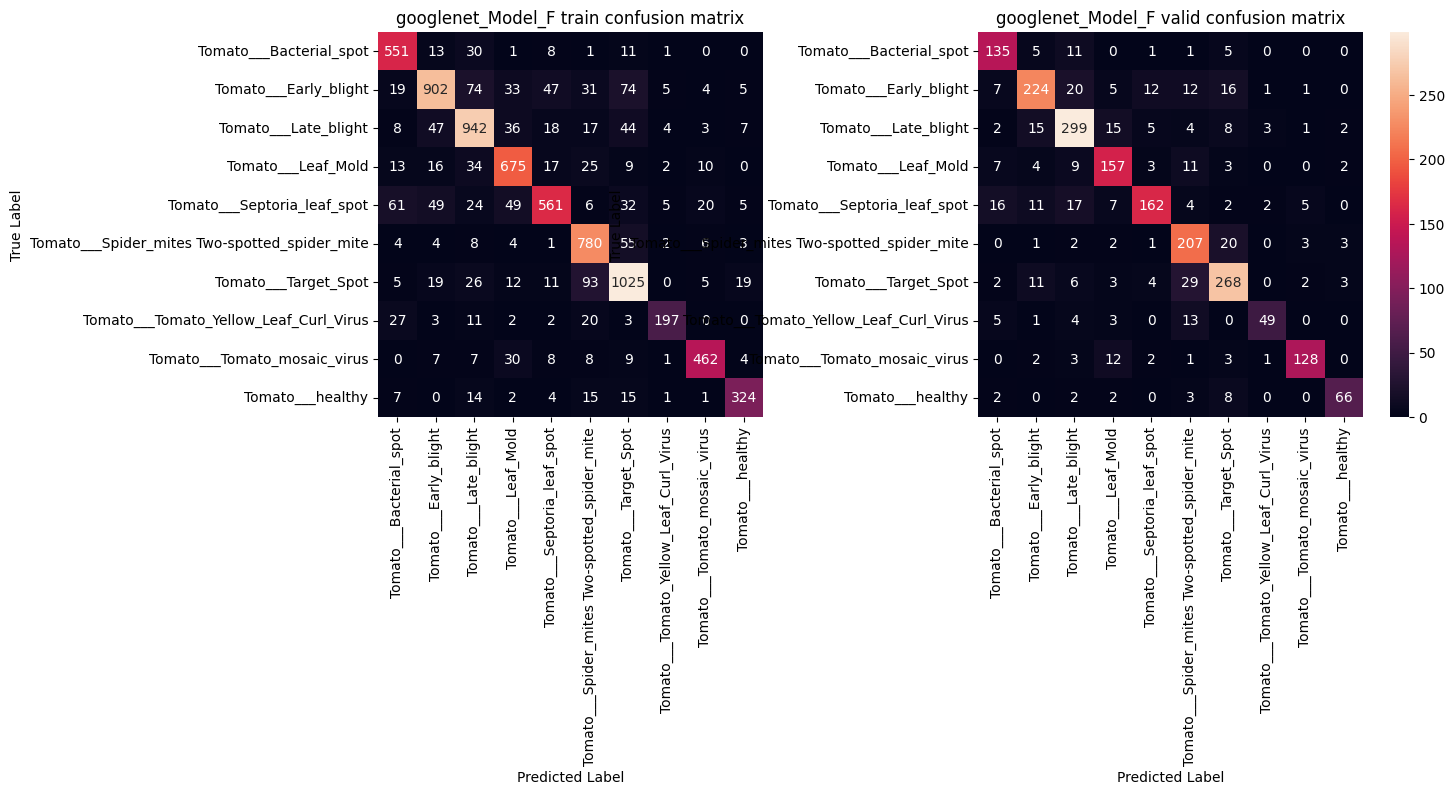

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

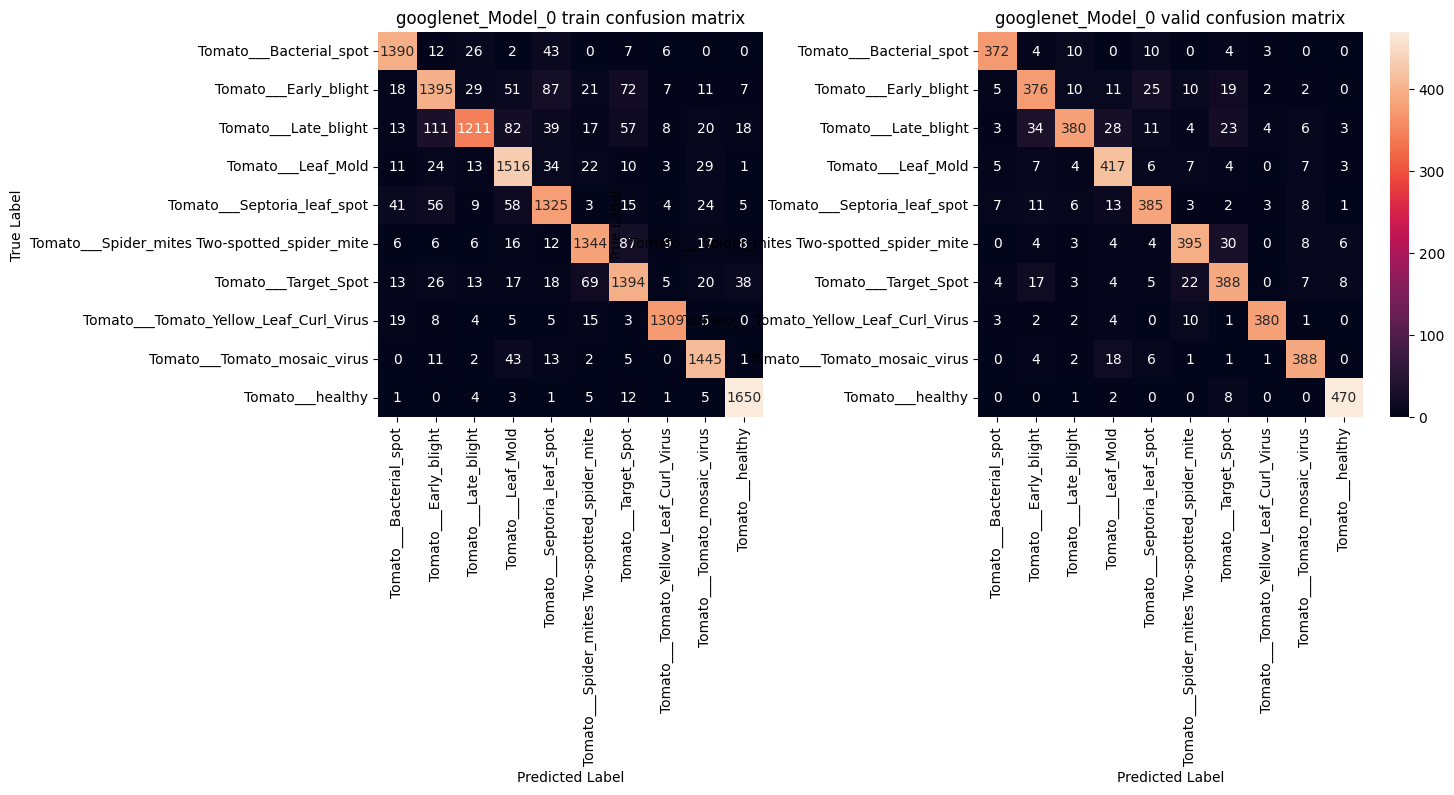

In [47]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

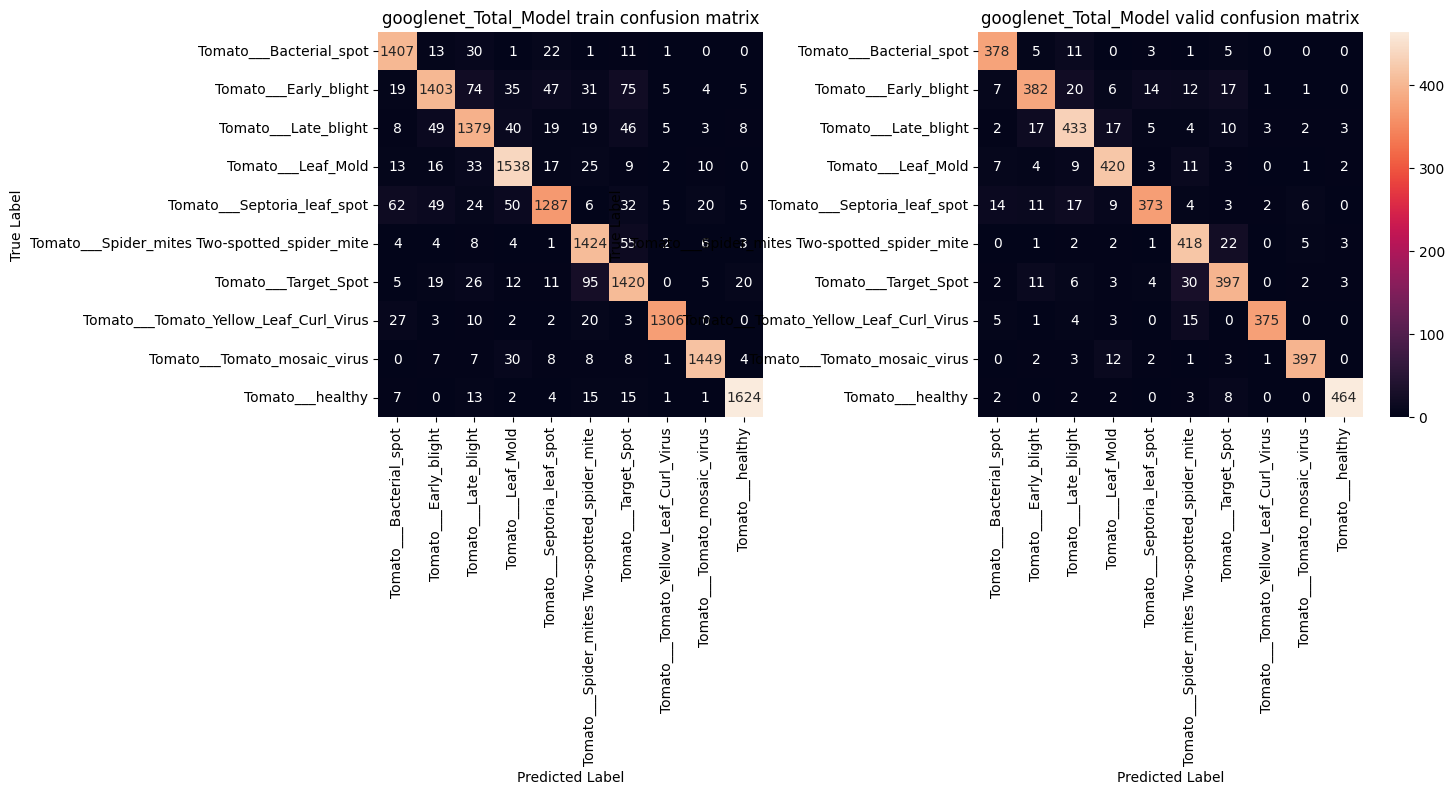

In [48]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")

In [49]:
torch.cuda.empty_cache()

In [50]:
# 創建一個空的DataFrame
df = pd.DataFrame(columns=['id','max_0','max_t', 'max_f','model_0_prob','model_t_prob', 'model_f_prob','model_0_pred', 'model_t_pred', 'model_f_pred','true_label','true_choose', 'correct','choose'])

# 遍歷驗證集中的每筆資料，並記錄相關資訊到DataFrame中
with torch.no_grad():
    for data, target, idx in valid_dl:
        
        data, target = data.to(device), target.to(device)

        out = model_0(data)
        out_t = model_T(data)
        out_f = model_F(data)
        
        # 取得模型的預測結果
        _, y_pred = torch.max(out, dim=1)
        _, y_pred_t = torch.max(out_t, dim=1)
        _, y_pred_f = torch.max(out_f, dim=1)
        
        # 取得模型的預測機率
        probs = torch.softmax(out, dim=1)
        probs_t = torch.softmax(out_t, dim=1)
        probs_f = torch.softmax(out_f, dim=1)
        # probs_f=temperature_scaling(probs_f,1.5)

        max_probs, _ = torch.max(probs, dim=1)
        max_probs_t, _ = torch.max(probs_t, dim=1)
        max_probs_f, _ = torch.max(probs_f, dim=1)
        
        
        choose=torch.zeros_like(target)
        choose[(max_probs_t >= max_probs_f)] = 0  # model_t
        choose[(max_probs_t < max_probs_f)] = 1  # model_f

        true_choose=torch.zeros_like(target)
        true_choose[(y_pred==target)] = 0  # model_t
        true_choose[(y_pred!=target)] = 1  # model_f

        # 取得是否預測正確的結果
        correct = torch.zeros_like(target)
        correct[(y_pred_t == target) & (y_pred_f == target)] = 0    # 兩個模型都預測對
        correct[(y_pred_t == target) & (y_pred_f != target)] = 1    # model_T 預測對
        correct[(y_pred_t != target) & (y_pred_f == target)] = 2    # model_F 預測對
        correct[(y_pred_t != target) & (y_pred_f != target)] = 3    # 兩個模型都預測錯誤

        
        # 將資訊添加到DataFrame中
        for i in range(len(idx)):
            data_id = idx[i].item()
            max_0=max_probs[i].item()
            max_t=max_probs_t[i].item()
            max_f=max_probs_f[i].item()
            model_prob = probs[i, target[i]].item()

            model_t_prob = probs_t[i, target[i]].item()
            model_t_pred = y_pred_t[i].item()
            model_f_prob = probs_f[i, target[i]].item()
            model_f_pred = y_pred_f[i].item()
            model_0_pred=y_pred[i].item()
            true_label=target[i].item()
            is_true_choose=true_choose[i].item()
            is_choose=choose[i].item()
            is_correct = correct[i].item()
            df = pd.concat([df, pd.DataFrame({'id': [data_id],'max_0':[max_0],'max_t':[max_t],'max_f':[max_f],'model_0_prob':[model_prob], 'model_t_prob': [model_t_prob], 'model_f_prob': [model_f_prob],'model_0_pred':[model_0_pred], 'model_t_pred': [model_t_pred], 'model_f_pred': [model_f_pred] ,'true_label': [true_label],'true_choose':[is_true_choose], 'correct': [is_correct],'choose': [is_choose]})], ignore_index=True)

df


,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
0,3051,0.438742,0.521328,0.498248,0.438742,0.140394,0.498248,1,3,1,1,0,2,0
1,20849,0.617785,0.629815,0.436667,0.617785,0.629815,0.436667,9,9,9,9,0,0,0
2,9552,0.757342,0.559727,0.646775,0.757342,0.559727,0.646775,4,4,4,4,0,0,1
3,15887,0.863132,0.832230,0.578089,0.863132,0.832230,0.578089,7,7,7,7,0,0,0
4,4461,0.858850,0.683765,0.777349,0.858850,0.683765,0.777349,1,1,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4470,5189,0.425192,0.474961,0.411287,0.136357,0.067548,0.181560,1,3,1,2,1,3,0
4471,13603,0.328061,0.561923,0.322327,0.272859,0.050626,0.322327,9,9,6,6,1,2,0
4472,8019,0.842590,0.819461,0.780408,0.842590,0.819461,0.780408,3,3,3,3,0,0,0
4473,11638,0.706904,0.584112,0.800888,0.706904,0.584112,0.800888,5,5,5,5,0,0,1


In [51]:
df[(df['true_choose']==0) & (df['choose']==1)]  #實際上應該是要用model_T但被分到用model_F

,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
2,9552,0.757342,0.559727,0.646775,0.757342,0.559727,0.646775,4,4,4,4,0,0,1
4,4461,0.858850,0.683765,0.777349,0.858850,0.683765,0.777349,1,1,1,1,0,0,1
7,12397,0.926870,0.910756,0.913005,0.926870,0.910756,0.913005,5,5,5,5,0,0,1
8,13873,0.694525,0.376405,0.692095,0.694525,0.376405,0.692095,6,6,6,6,0,0,1
11,19400,0.567410,0.326636,0.675789,0.567410,0.283813,0.675789,8,3,8,8,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4456,12777,0.582145,0.599523,0.616160,0.582145,0.599523,0.616160,5,5,5,5,0,0,1
4458,2848,0.586074,0.519396,0.569421,0.586074,0.260442,0.569421,1,4,1,1,0,2,1
4464,9596,0.413738,0.282979,0.368627,0.413738,0.155795,0.368627,4,3,4,4,0,2,1
4466,2114,0.796493,0.605522,0.776877,0.796493,0.605522,0.776877,0,0,0,0,0,0,1


In [52]:
len(df[(df['true_choose']==0) & (df['choose']==1)&(df['model_f_pred']==df['true_label'])] ) #實際上應該是要用model_T但被分到用model_F但是有分類正確

1619

In [53]:
df[(df['true_choose']==1) & (df['choose']==0)]  #實際上應該是要用model_F但被分到用model_T

,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
20,14812,0.246323,0.546607,0.250710,0.202854,0.214115,0.213860,1,9,4,6,1,3,0
29,11908,0.653798,0.596811,0.571482,0.193995,0.098874,0.316482,6,6,6,5,1,3,0
120,14876,0.396394,0.512923,0.405598,0.150656,0.073986,0.173138,3,9,3,6,1,3,0
123,13074,0.813360,0.718564,0.523536,0.091445,0.122682,0.284877,8,8,8,5,1,3,0
127,10739,0.458978,0.642953,0.460586,0.278014,0.197469,0.206631,5,5,5,4,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4431,9297,0.424800,0.652102,0.365971,0.157702,0.039432,0.190469,1,0,0,4,1,3,0
4433,6209,0.362965,0.324563,0.299354,0.075627,0.006238,0.131934,1,5,1,2,1,3,0
4468,11045,0.498413,0.571167,0.536753,0.050542,0.036880,0.038234,5,5,5,4,1,3,0
4470,5189,0.425192,0.474961,0.411287,0.136357,0.067548,0.181560,1,3,1,2,1,3,0


In [54]:
len(df[(df['true_choose']==1) & (df['choose']==0)&(df['model_t_pred']==df['true_label'])] ) #實際上應該是要用model_F但被分到用model_T但有分類正確

19

In [55]:
df[(df['model_0_pred']==df['true_label']) & (df['model_t_pred']!=df['true_label']) & (df['model_f_pred']!=df['true_label'])] 

,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
124,19606,0.324492,0.253274,0.369262,0.324492,0.219261,0.270260,8,7,2,8,0,3,1
202,15197,0.311518,0.409794,0.268881,0.311518,0.220749,0.188056,6,0,2,6,0,3,0
424,10354,0.472800,0.490218,0.468728,0.472800,0.260261,0.357297,4,0,0,4,0,3,0
514,9754,0.372872,0.562492,0.329148,0.372872,0.203669,0.275828,4,0,1,4,0,3,0
607,14740,0.517546,0.583863,0.574355,0.517546,0.244426,0.371573,6,5,5,6,0,3,0
704,15188,0.477070,0.563291,0.619541,0.477070,0.294491,0.316891,6,5,5,6,0,3,1
811,15189,0.452836,0.557226,0.441592,0.452836,0.152243,0.409802,6,5,5,6,0,3,0
1408,2472,0.300800,0.366643,0.399062,0.300800,0.121832,0.208671,1,3,2,1,0,3,1
1470,10682,0.403186,0.360798,0.337023,0.403186,0.138493,0.329284,4,6,6,4,0,3,0
1536,3317,0.358194,0.572526,0.384305,0.358194,0.148029,0.273945,1,3,2,1,0,3,0


In [56]:
with torch.no_grad():
    false_T=0
    false_F=0
    for data,target,idx in valid_dl:

        outputs=[]
        data,target=data.to(device),target.to(device)
        out=model_0(data)

        softmax = torch.nn.functional.softmax(out, dim=1)
        
        for d,t in zip(data,target):

            out_f=model_F(d.unsqueeze(0))
            out_t=model_T(d.unsqueeze(0))
            
            softmax_F = torch.softmax(out_f, dim=1)
            softmax_T = torch.softmax(out_t, dim=1)


            # temperature1 = 1.5
            # temperature2 = 0.3

            # # 對預測概率進行溫度調整
            # softmax_F = torch.exp(softmax_F / temperature1) / torch.exp(softmax_F / temperature1).sum(dim=1, keepdim=True)
            # softmax_T = torch.exp(softmax_T / temperature2) / torch.exp(softmax_T / temperature2).sum(dim=1, keepdim=True)

            

            # softmax_F=sorted(softmax_F,reverse=True)
            # value_F=softmax_F[0]-softmax_F[1]

            # softmax_T=sorted(softmax_T,reverse=True)
            # value_T=softmax_T[0]-softmax_T[1]
            out=model_0(d.unsqueeze(0))
            _,y_pred_tag=torch.max(out, dim = 1)
            if(softmax_T.max()>softmax_F.max()):
                
                if (t!=y_pred_tag).item():
                    false_T+=1
            else:

                if (t==y_pred_tag).item():
                    false_F+=1

false_T,false_F

(345, 1638)

In [57]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [58]:
def temperature_scaling(logits, temperature):
    """
    使用溫度調整方法校準模型的預測機率
    
    參數：
        logits：模型的輸出（未經softmax處理的輸出）
        temperature：溫度參數
        
    返回：
        prob：校準後的預測機率
    """
    prob = torch.softmax(logits / temperature, dim=1)
    return prob

In [59]:
# 使用計算 ECE 的函式
def calculate_ece(model, dataloader, num_bins=10):
    model.eval()
    total_samples = len(dataloader.dataset)
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_confidence = np.zeros(num_bins)
    bin_accuracy = np.zeros(num_bins)
    bin_samples = np.zeros(num_bins)
    ece = 0.0

    with torch.no_grad():
        for images, labels,idx in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            softmax_probs = torch.softmax(outputs, dim=1)
            
            softmax_probs=temperature_scaling(softmax_probs,0.1)
            
            confidences, predictions = torch.max(softmax_probs, dim=1)
            correct_predictions = predictions.eq(labels)

            for i in range(num_bins):
                mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
                
                num_samples = mask.sum().item()
                if num_samples > 0:
                    accuracy = correct_predictions[mask].sum().item() / num_samples
                    confidence = confidences[mask].mean().item()
                    bin_confidence[i] += confidence
                    bin_accuracy[i] += accuracy
                    bin_samples[i] += num_samples

    for i in range(num_bins):
        if bin_samples[i] > 0:
            avg_confidence = bin_confidence[i] / bin_samples[i]
            accuracy = bin_accuracy[i] / bin_samples[i]
            ece += np.abs(accuracy - avg_confidence) * (bin_samples[i] / total_samples)

    return ece


ece = calculate_ece(model_T, train_dl)
print(f"ECE: {ece}")

ECE: 0.022803775011479722


In [60]:
# 定義一個校準方法來獲得可信度分數
def calibration_curve(model, data_dl):
    model.eval()
    with torch.no_grad():
        confidences = []
        for data, target, _ in data_dl:
            data, target = data.cuda(), target.cuda()
            out = model(data)
            prob = torch.softmax(out, dim=1)
            confidence = torch.max(prob, dim=1).values
            confidences.append(confidence.cpu().numpy())
        
        confidences = np.concatenate(confidences)
        return confidences

# 使用校準方法獲得可信度分數
confidences = calibration_curve(model_0, valid_dl)

# 可信度分數範圍介於 0 和 1 之間，越接近 1 表示模型對於該預測越自信
print(confidences)

[0.69824666 0.6157114  0.74024546 ... 0.49496275 0.702138   0.8553812 ]
